In [24]:
import pandas as pd

path = r"C:\Users\Hooshmand\Desktop\secondary-structure.data"

data = []
start = False

with open(path, encoding="latin1") as f:
    for line in f:
        line = line.strip()

        # رد کردن هدرها (ایمیل‌ها)
        if not start:
            if line and line[0].isdigit():
                start = True
            else:
                continue

        # حذف خطوط خراب
        if "<" in line or "Message" in line:
            continue

        parts = line.split()

        # فقط خطوط واقعی
        if len(parts) >= 2 and parts[0].isdigit():
            data.append(parts)

df = pd.DataFrame(data)
print(df.head())
print(df.shape)

Empty DataFrame
Columns: []
Index: []
(0, 0)


In [25]:
import pandas as pd

path = r"C:\Users\Hooshmand\Desktop\secondary-structure.data"

rows = []
recording = False

with open(path, encoding="latin1") as f:
    for line in f:
        line = line.strip()

        # شروع داده واقعی (وقتی به عددها می‌رسیم)
        if line and line[0].isdigit() and not recording:
            recording = True

        # رد کردن header و ایمیل‌ها
        if not recording:
            continue

        # حذف نویزها
        if "Message" in line or "<" in line:
            continue

        parts = line.split()

        # فقط خطوط واقعی داده
        if len(parts) >= 2:
            rows.append(parts)

# ساخت DataFrame
df = pd.DataFrame(rows)

print(df.head())
print(df.shape)

     0  1  2     3
0  GLY  _  1  0.03
1  VAL  _  1  0.09
2  GLY  _  1  0.15
3  THR  _  1  0.17
4  VAL  _  1  0.24
(21324, 4)


In [26]:
print(df.head(20))
print(df[2].value_counts().head())

      0  1  2     3
0   GLY  _  1  0.03
1   VAL  _  1  0.09
2   GLY  _  1  0.15
3   THR  _  1  0.17
4   VAL  _  1  0.24
5   PRO  _  1  0.45
6   MET  _  1  0.44
7   THR  _  1  0.34
8   ASP  _  1  0.35
9   TYR  _  1  0.31
10  GLY  _  1  0.36
11  ASN  _  1  0.33
12  ASP  _  1  0.24
13  VAL  _  1  0.22
14  GLU  _  1  0.10
15  TYR  _  1  0.01
16  TYR  _  1  0.05
17  GLY  _  1  0.08
18  GLN  _  1  0.18
19  VAL  E  1  0.23
2
1    21324
Name: count, dtype: int64


In [27]:
df.columns = ["AA", "Structure", "Protein_ID", "Position"]

In [29]:
X = df[["AA", "Position"]]
y = df["Structure"]

In [35]:
df.iloc[:, :10].head()

,AA,Structure,Protein_ID,Position,AA_enc
0,GLY,_,1,0.03,7
1,VAL,_,1,0.09,19
2,GLY,_,1,0.15,7
3,THR,_,1,0.17,16
4,VAL,_,1,0.24,19


In [36]:
df["Structure"].value_counts()

Structure
_    11499
H     5470
E     4355
Name: count, dtype: int64

In [37]:
pd.crosstab(df["AA"], df["Structure"])

Structure,E,H,_
AA,,,
ALA,282,691,882
ARG,146,199,363
ASN,119,207,671
ASP,112,272,811
CYS,122,101,257
GLN,151,232,381
GLU,130,399,509
GLY,256,247,1334
HIS,77,148,287


In [38]:
from sklearn.cluster import KMeans


X = df[["AA_enc", "Position"]]


kmeans = KMeans(n_clusters=3, random_state=42)


df["Cluster"] = kmeans.fit_predict(X)


print(df.head())

    AA Structure Protein_ID Position  AA_enc  Cluster
0  GLY         _          1     0.03       7        1
1  VAL         _          1     0.09      19        0
2  GLY         _          1     0.15       7        1
3  THR         _          1     0.17      16        0
4  VAL         _          1     0.24      19        0


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["AA_enc"] = le.fit_transform(df["AA"])

In [40]:
df["Cluster"].value_counts()

Cluster
1    7879
0    7446
2    5999
Name: count, dtype: int64

In [42]:
df.dtypes

AA            object
Structure     object
Protein_ID    object
Position      object
AA_enc         int64
Cluster        int32
dtype: object

In [43]:
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

In [44]:
df.groupby("Cluster")["Position"].mean()

Cluster
0    0.268633
1    0.289730
2    0.286186
Name: Position, dtype: float64

In [45]:
pd.crosstab(df["Cluster"], df["AA"])

AA,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,818,970,1621,1396,315,737,1589
1,0,0,0,0,0,0,1038,1837,512,995,1707,1448,342,0,0,0,0,0,0,0
2,1855,708,997,1195,480,764,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [46]:
pd.crosstab(df["Cluster"], df["AA"]).T

Cluster,0,1,2
AA,,,
ALA,0,0,1855
ARG,0,0,708
ASN,0,0,997
ASP,0,0,1195
CYS,0,0,480
GLN,0,0,764
GLU,0,1038,0
GLY,0,1837,0
HIS,0,512,0


In [47]:
pd.crosstab(df["Cluster"], df["AA"]).head(10)

AA,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,818,970,1621,1396,315,737,1589
1,0,0,0,0,0,0,1038,1837,512,995,1707,1448,342,0,0,0,0,0,0,0
2,1855,708,997,1195,480,764,0,0,0,0,0,0,0,0,0,0,0,0,0,0


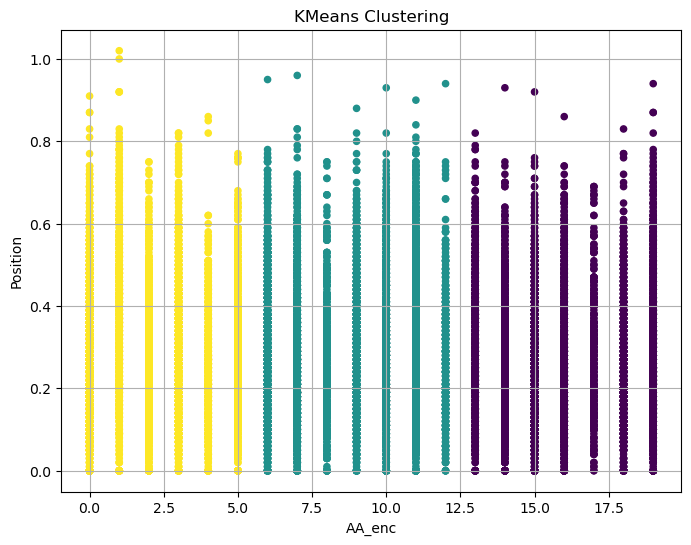

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["AA_enc"],df["Position"],c=df["Cluster"],s=20)

plt.xlabel("AA_enc")
plt.ylabel("Position")
plt.title("KMeans Clustering")
plt.grid(True)

plt.show()